In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 60, 3, padding=1, groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model31_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model31_0)
describe(model31_0)

MACs: 4.32 MMac, Params: 29.25 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model31_0.pt
Starting
Epoch 1/60: Train loss = 1.0989, Train accuracy = 0.6108, Test loss = 1.0611, Test accuracy = 0.6234
Epoch 2/60: Train loss = 1.0332, Train accuracy = 0.6328, Test loss = 0.9853, Test accuracy = 0.6481
Epoch 3/60: Train loss = 0.8360, Train accuracy = 0.7063, Test loss = 0.8175, Test accuracy = 0.7110
Epoch 4/60: Train loss = 0.8220, Train accuracy = 0.7164, Test loss = 0.8103, Test accuracy = 0.7198
Epoch 5/60: Train loss = 0.7646, Train accuracy = 0.7291, Test loss = 0.7500, Test accuracy = 0.7367
Epoch 6/60: Train loss = 0.7485, Train accuracy = 0.7420, Test loss = 0.7463, Test accuracy = 0.7400
Epoch 7/60: Train loss = 0.6909, Train accuracy = 0.7598, Test loss = 0.7156, Test accuracy = 0.7530
Epoch 8/60: Train loss = 0.6372, Train accuracy = 0.7755, Test loss = 0.6489, Test accuracy = 0.7753
Epoch 9/60: Train loss = 0.6223, Train accuracy = 0.7826, Test loss = 0.6330, Test accuracy = 0.7799
Epoch 10/60: Train loss = 0.696

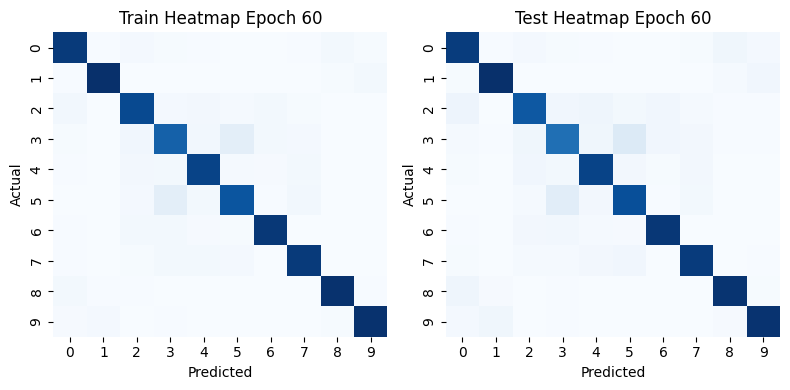

<Figure size 1200x600 with 0 Axes>

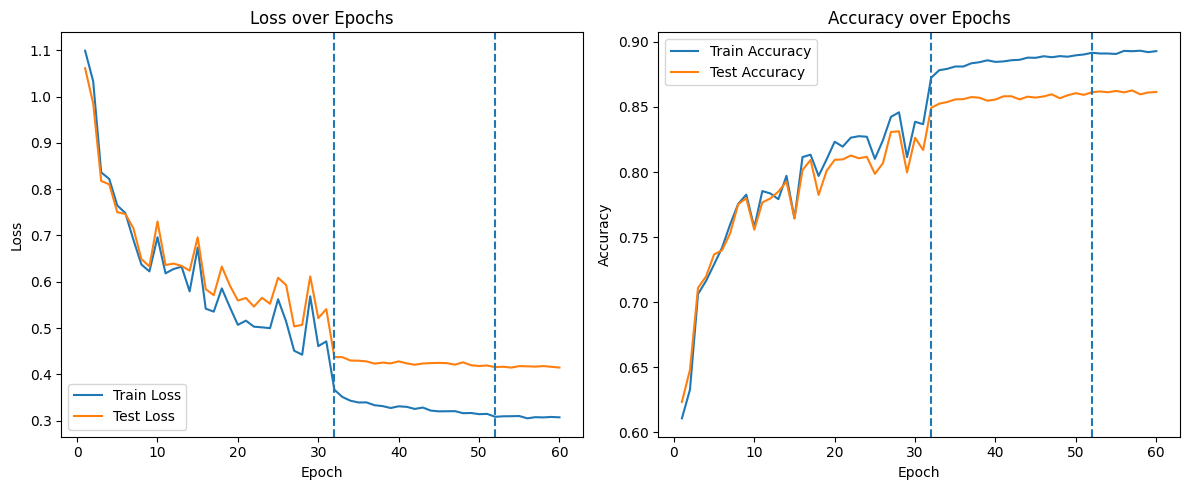

In [6]:
trainf32(model31_0,"model_weights/model31_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model31_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model31_1)
describe(model31_1)

MACs: 4.32 MMac, Params: 29.25 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model31_1.pt
Starting
Epoch 1/60: Train loss = 1.2269, Train accuracy = 0.5839, Test loss = 1.2074, Test accuracy = 0.5955
Epoch 2/60: Train loss = 0.9108, Train accuracy = 0.6773, Test loss = 0.8790, Test accuracy = 0.6909
Epoch 3/60: Train loss = 0.7550, Train accuracy = 0.7311, Test loss = 0.7616, Test accuracy = 0.7321
Epoch 4/60: Train loss = 0.7320, Train accuracy = 0.7414, Test loss = 0.7128, Test accuracy = 0.7518
Epoch 5/60: Train loss = 0.9844, Train accuracy = 0.6817, Test loss = 0.9591, Test accuracy = 0.6829
Epoch 6/60: Train loss = 0.6947, Train accuracy = 0.7618, Test loss = 0.6981, Test accuracy = 0.7618
Epoch 7/60: Train loss = 0.6590, Train accuracy = 0.7768, Test loss = 0.6730, Test accuracy = 0.7757
Epoch 8/60: Train loss = 0.6478, Train accuracy = 0.7745, Test loss = 0.6860, Test accuracy = 0.7653
Epoch 9/60: Train loss = 0.6181, Train accuracy = 0.7844, Test loss = 0.6227, Test accuracy = 0.7857
Epoch 10/60: Train loss = 0.705

/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 29/60: Train loss = 0.4738, Train accuracy = 0.8358, Test loss = 0.5347, Test accuracy = 0.8207
Epoch 30/60: Train loss = 0.4527, Train accuracy = 0.8425, Test loss = 0.5223, Test accuracy = 0.8159
Epoch 31/60: Train loss = 0.4535, Train accuracy = 0.8400, Test loss = 0.4991, Test accuracy = 0.8344
Epoch 32/60: Train loss = 0.3569, Train accuracy = 0.8757, Test loss = 0.4314, Test accuracy = 0.8546
Epoch 33/60: Train loss = 0.3512, Train accuracy = 0.8777, Test loss = 0.4294, Test accuracy = 0.8542
Epoch 34/60: Train loss = 0.3439, Train accuracy = 0.8783, Test loss = 0.4232, Test accuracy = 0.8580
Epoch 35/60: Train loss = 0.3424, Train accuracy = 0.8798, Test loss = 0.4240, Test accuracy = 0.8560
Epoch 36/60: Train loss = 0.3372, Train accuracy = 0.8817, Test loss = 0.4207, Test accuracy = 0.8567
Epoch 37/60: Train loss = 0.3357, Train accuracy = 0.8818, Test loss = 0.4160, Test accuracy = 0.8587
Epoch 38/60: Train loss = 0.3348, Train accuracy = 0.8817, Test loss = 0.4202, Tes

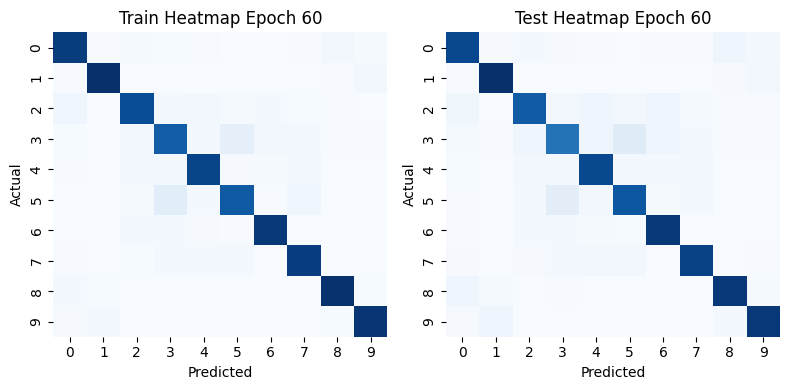

<Figure size 1200x600 with 0 Axes>

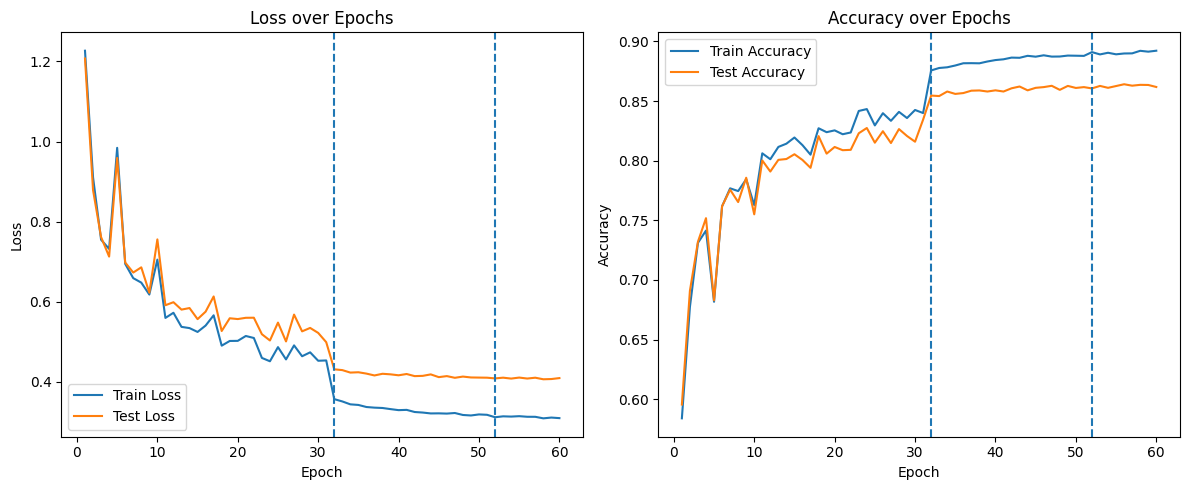

In [8]:
trainf32(model31_1,"model_weights/model31_1.pt",criterion,train_dataset,val_dataset, batch_size=64)